<a href="https://colab.research.google.com/github/ASHIKAJAN/ABC-staff-company/blob/main/AI_and_GenAI_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
BUFFER_SIZE=60000
BATCH_SIZE=256
EPOCHS=20
NOISE_DIM=100

In [ ]:
(x_train,_),(_,_) = tf.keras.datasets.mnist.load_data()
x_train=(x_train.astype("float32")-127.5)/127.5
x_train=x_train.reshape((-1,28,28,1))
dataset=tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def make_generator():
    return tf.keras.Sequential([
        layers.Dense(7*7*256,use_bias=False,input_shape=(NOISE_DIM,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Reshape((7,7,256)),
        layers.Conv2DTranspose(128,5,strides=1,padding="same",use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(64,5,strides=2,padding="same",use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),
        layers.Conv2DTranspose(1,5,strides=2,padding="same",use_bias=False,activation="tanh")
    ])

In [ ]:
def make_discriminator():
    return tf.keras.Sequential([
        layers.Conv2D(64,5,strides=2,padding="same",input_shape=(28,28,1)),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Conv2D(128,5,strides=2,padding="same"),
        layers.LeakyReLU(),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1,activation="sigmoid")
    ])

In [ ]:
generator=make_generator()
discriminator=make_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
bce=tf.keras.losses.BinaryCrossentropy()
g_opt=tf.keras.optimizers.Adam(0.0002,beta_1=0.5)
d_opt=tf.keras.optimizers.Adam(0.0002,beta_1=0.5)

In [ ]:
g_losses=[]; d_losses=[]
seed=tf.random.normal([16,NOISE_DIM])

In [ ]:
@tf.function
def train_step(images):
    noise=tf.random.normal([tf.shape(images)[0],NOISE_DIM])
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake=generator(noise,training=True)
        real_out=discriminator(images,training=True)
        fake_out=discriminator(fake,training=True)
        g_loss=bce(tf.ones_like(fake_out),fake_out)
        d_loss=bce(tf.ones_like(real_out),real_out)+bce(tf.zeros_like(fake_out),fake_out)
    g_opt.apply_gradients(zip(gt.gradient(g_loss,generator.trainable_variables),generator.trainable_variables))
    d_opt.apply_gradients(zip(dt.gradient(d_loss,discriminator.trainable_variables),discriminator.trainable_variables))
    return g_loss,d_loss

In [ ]:
def generate(epoch):
    preds=generator(seed,training=False)
    plt.figure(figsize=(4,4))
    for i in range(16):
        plt.subplot(4,4,i+1)
        plt.imshow(preds[i,:,:,0]*127.5+127.5,cmap='gray')
        plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"generated_epoch_{epoch}.png")
    plt.close()

In [15]:
for epoch in range(1,EPOCHS+1):
    for batch in dataset:
        gl,dl=train_step(batch)
    g_losses.append(float(gl)); d_losses.append(float(dl))
    if epoch%5==0:
        generate(epoch)
        print(f"Epoch {epoch}: G={gl:.4f}, D={dl:.4f}")

Epoch 5: G=0.9072, D=1.1630


KeyboardInterrupt: 

Training complete.


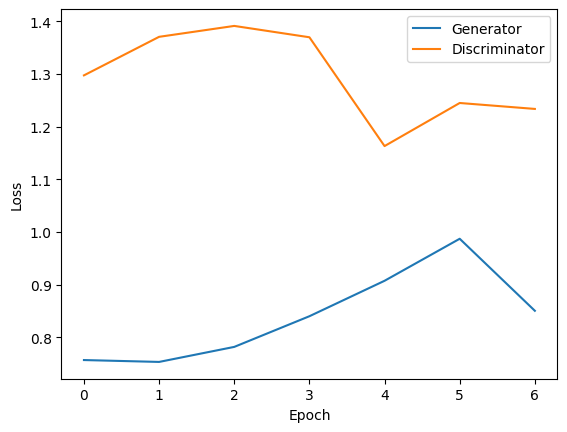

In [16]:
plt.plot(g_losses,label="Generator")
plt.plot(d_losses,label="Discriminator")
plt.legend(); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.savefig("loss_curve.png")
print("Training complete.")